# Bayesian Optimization To Enhance Tire Compound Durability

This notebook uses Bayesian Optimization to enhance durability of tires, an important factor in commuter cars as well as endurance racers where tires must balance performance with longevity. BO is used to minimize wear (abrasion) and heat generation (rolling resistance) that leads to excessive wear.

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process.kernels import RationalQuadratic
import umap
from sklearn.decomposition import KernelPCA
from sklearn.gaussian_process.kernels import Matern
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

In [93]:
param_names = ["vulc_time", "vulc_temp", "sulph_MP", "carbB_MP", "mixer_set", "carbB_grade"]
param_bounds = np.array([[300, 1000], [403, 453], [1, 10], [1, 35], [1, 11], [1, 100]])
integer_params = [0, 1, 2, 3, 4, 5]
output_names = ["material_cost", "heating_cost", "mixing_cost", "sound_damping", "rolling_resistance", "abrasion", "dry_grip", "wet_grip"]

scaler = MinMaxScaler()
scaler.fit(param_bounds.T)

def UCB(mean, std, beta=1.0):
    return mean + beta*std

def PI(mean, std, c=1.5):
    z = (mean.max() * c - mean) / std
    return 1-norm.cdf(z)

def EI(mean, std):
    d = mean - mean.max()
    z = -d / std
    return d*(1-norm.cdf(z)) + std*norm.pdf(z)

def NextPoint(gp, X_train, y_train, n_candidates=50000, seed=None): 
    # The 'candidates' are randomly sampled points across the 6D parameter space.
        # Trained GP predicts mean and std at each candidate --> scored by EI to find next experiment to run.
    rng = np.random.default_rng(seed)
    gp.fit(scaler.transform(X_train.T), y_train)
    
    X_cand = np.zeros((6, n_candidates))
    for i in range(6): X_cand[i] = rng.uniform(param_bounds[i, 0], param_bounds[i, 1], n_candidates)
    for idx in integer_params: X_cand[idx] = np.round(X_cand[idx]).clip(param_bounds[idx, 0], param_bounds[idx, 1])
    
    y_pred, y_std = gp.predict(scaler.transform(X_cand.T), return_std=True)
    
    ei_vals = EI(y_pred, y_std)
    i_next = np.argmax(ei_vals)
    x_next = X_cand[:, i_next]
    
    return x_next

## Initialization Data (The first 5 Points)

In [94]:
X_train = np.array([
    [650, 428, 5, 18, 6, 50],
    [750, 447, 7, 24, 5, 70],
    [458, 415, 3, 10, 2, 32],
    [899, 405, 1, 32, 8, 91],
    [377, 435, 9,  2, 11, 5]], dtype=float).T

results = [
    {"material_cost": 652.32347, "heating_cost": 11.875, "mixing_cost": 29.1222,
     "sound_damping": 0.08635321149188717, "rolling_resistance": 0.1772650074126504,
     "abrasion": 343.1309573700778, "dry_grip": 0.00305106876599966, "wet_grip": 4.79231477},

    {"material_cost": 1047.667708, "heating_cost": 15.120000000000001, "mixing_cost": 24.2685,
     "sound_damping": 0.06799501536549545, "rolling_resistance": 0.14040888545605992,
     "abrasion": 272.4793710784738, "dry_grip": 0.001745032386087494, "wet_grip": 7.04167872},
     
    {"material_cost": 364.45193199999994, "heating_cost": 8.489600000000001, "mixing_cost": 9.7074,
     "sound_damping": 0.13081222478416077, "rolling_resistance": 0.3102083267734656,
     "abrasion": 428.94298432566035, "dry_grip": 0.007346797785537304, "wet_grip": 1.584387198},

    {"material_cost": 1650.0819032, "heating_cost": 12.229800000000001, "mixing_cost": 38.8296,
     "sound_damping": 0.07903992534389295, "rolling_resistance": 0.23287878215460714,
     "abrasion": 241.6363501179152, "dry_grip": 0.009752820430088745, "wet_grip": 8.90681416},

    {"material_cost": 237.91522099999997, "heating_cost": 8.9364, "mixing_cost": 53.390699999999995,
     "sound_damping": 0.11211089049998915, "rolling_resistance": 0.15593618360022096,
     "abrasion": 5794.259219712325, "dry_grip": 0.0007438244399266374, "wet_grip": 0.876630396}
]

n_init = X_train.shape[1]
all_outputs = {name: np.array([r[name] for r in results]) for name in output_names}

print("Initial data:")
for i in range(n_init):
    print(f"  Point {i+1}: abrasion={results[i]['abrasion']:.2f}, "
          f"rolling_res={results[i]['rolling_resistance']:.6f}, "
          f"dry_grip={results[i]['dry_grip']:.6f}")

Initial data:
  Point 1: abrasion=343.13, rolling_res=0.177265, dry_grip=0.003051
  Point 2: abrasion=272.48, rolling_res=0.140409, dry_grip=0.001745
  Point 3: abrasion=428.94, rolling_res=0.310208, dry_grip=0.007347
  Point 4: abrasion=241.64, rolling_res=0.232879, dry_grip=0.009753
  Point 5: abrasion=5794.26, rolling_res=0.155936, dry_grip=0.000744


---
## Optimization #1: Abrasion Minimization

The goal of the following Bayesian Optimization is to develop a new set of features for the tire fabrication method, that minimizes abrasion (increases longevity and durability of the tire). 


Process: Initialize --> negate (abrasion must be minimized) --> fit GP --> generate 50,000 test points --> score using EI --> run experiment --> append and repeat until 20 iterations

For this optimization, I decided to use the RationalQuadratic kernel for the GP, based on the smoother response it produced when I tested it against the default RBF kernel for a test function (the previous assignment). 

In [95]:
gp_abrasion = GaussianProcessRegressor(kernel=RationalQuadratic())

X_train_Abr = X_train.copy()
Y_train_Abr = -all_outputs["abrasion"].copy() # negated
all_outputs_Abr = {name: all_outputs[name].copy() for name in output_names}

i_best = np.argmax(Y_train_Abr)
print(f"Current best abrasion: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

Current best abrasion: 241.6364 (Point 4)


### Opt1: Iteration #1

In [96]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=6)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 677
---vulc_temp: 450
---sulph_MP: 3
---carbB_MP: 6
---mixer_set: 10
---carbB_grade: 72


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [97]:
new_Abrasion_Iter1 = {
    "material_cost": 430.7501352,
    "heating_cost": 14.361900000000002,
    "mixing_cost": 48.537,
    "sound_damping": 0.11276532534474222,
    "rolling_resistance": 0.23451200888843493,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.004568967954451768,
    "wet_grip": 2.28637837
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter1["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter1[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter1['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 428.9430
Current best abrasion value: 241.6364 (Point 4)


These 2 cells repeat 20 times, once per iteration. The first cell calls the NextPoint function, which fits the GP on all observations so far, generates 50,000 random testing points across the 6D parameter space, scores each point using the EI acquisition function, and returns the highest-scoring parameter set to test next. The second cell records the experimental result and appends it to the training data.

### Opt1: Iteration #2

In [98]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=7)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 738
---vulc_temp: 422
---sulph_MP: 7
---carbB_MP: 24
---mixer_set: 1
---carbB_grade: 96


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [99]:
new_Abrasion_Iter2 = {
    "material_cost": 1369.7366344,
    "heating_cost": 12.3522,
    "mixing_cost": 4.8537,
    "sound_damping": 0.06643378585973458,
    "rolling_resistance": 0.1469284344692145,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0021001776400462182,
    "wet_grip": 7.58894205
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter2["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter2[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter2['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 272.4794
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #3

In [100]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=8)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 529
---vulc_temp: 421
---sulph_MP: 3
---carbB_MP: 14
---mixer_set: 11
---carbB_grade: 79


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [101]:
new_Abrasion_Iter3 = {
    "material_cost": 761.6439465999999,
    "heating_cost": 9.7822,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09082313725351351,
    "rolling_resistance": 0.2274941725540011,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.0070476822868834835,
    "wet_grip": 4.90280673
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter3["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter3[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter3['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #4

In [102]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=9)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 909
---vulc_temp: 435
---sulph_MP: 9
---carbB_MP: 33
---mixer_set: 2
---carbB_grade: 21


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [103]:
new_Abrasion_Iter4 = {
    "material_cost": 524.6312373,
    "heating_cost": 15.9588,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07596875587301481,
    "rolling_resistance": 0.11893139879067634,
    "abrasion": 670.8997908072586,
    "dry_grip": 0.0007832441316294921,
    "wet_grip": 5.03772453
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter4["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter4[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter4['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 670.8998
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #5

In [104]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=10)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 969
---vulc_temp: 445
---sulph_MP: 2
---carbB_MP: 34
---mixer_set: 6
---carbB_grade: 45


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [105]:
new_Abrasion_Iter5 = {
    "material_cost": 935.2835930000001,
    "heating_cost": 18.019800000000004,
    "mixing_cost": 29.1222,
    "sound_damping": 0.08104472798760967,
    "rolling_resistance": 0.21494608526295128,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.006010715254637283,
    "wet_grip": 7.947625820000001
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter5["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter5[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter5['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #6

In [106]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=11)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 390
---vulc_temp: 429
---sulph_MP: 7
---carbB_MP: 8
---mixer_set: 5
---carbB_grade: 19


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [107]:
new_Abrasion_Iter6 = {
    "material_cost": 292.9755872,
    "heating_cost": 8.694,
    "mixing_cost": 24.2685,
    "sound_damping": 0.11742190393672483,
    "rolling_resistance": 0.1903211401292849,
    "abrasion": 670.8997908072586,
    "dry_grip": 0.001568342918092106,
    "wet_grip": 1.265845895
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter6["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter6[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter6['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 670.8998
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #7

In [108]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=12)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 945
---vulc_temp: 422
---sulph_MP: 2
---carbB_MP: 32
---mixer_set: 1
---carbB_grade: 96


In [109]:
new_Abrasion_Iter7 = {
    "material_cost": 1735.4109392,
    "heating_cost": 14.8155,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07575127707831106,
    "rolling_resistance": 0.20774790402301493,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.006407631189896646,
    "wet_grip": 8.74729663
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter7["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter7[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter7['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #8

In [110]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=13)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 980
---vulc_temp: 425
---sulph_MP: 2
---carbB_MP: 34
---mixer_set: 1
---carbB_grade: 98


In [111]:
new_Abrasion_Iter8 = {
    "material_cost": 1865.3608452,
    "heating_cost": 15.616,
    "mixing_cost": 4.8537,
    "sound_damping": 0.0753614424263767,
    "rolling_resistance": 0.20649505355791414,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.0061090717058532315,
    "wet_grip": 9.08963651
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter8["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter8[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter8['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #9

In [112]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=14)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 958
---vulc_temp: 413
---sulph_MP: 1
---carbB_MP: 31
---mixer_set: 1
---carbB_grade: 100


In [113]:
new_Abrasion_Iter9 = {
    "material_cost": 1749.23823,
    "heating_cost": 13.838,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07914484809324324,
    "rolling_resistance": 0.23187102507478213,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009854364549192363,
    "wet_grip": 8.55475395
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter9["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter9[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter9['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #10

In [114]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=15)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 990
---vulc_temp: 435
---sulph_MP: 2
---carbB_MP: 35
---mixer_set: 2
---carbB_grade: 98


In [115]:
new_Abrasion_Iter10 = {
    "material_cost": 1913.819443,
    "heating_cost": 17.028,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07526209360105596,
    "rolling_resistance": 0.20547520059567695,
    "abrasion": 254.52938597996484,
    "dry_grip": 0.005913260400354733,
    "wet_grip": 9.17774409
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter10["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter10[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter10['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 254.5294
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #11

In [116]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=16)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 966
---vulc_temp: 409
---sulph_MP: 1
---carbB_MP: 32
---mixer_set: 2
---carbB_grade: 89


In [117]:
new_Abrasion_Iter11 = {
    "material_cost": 1617.0491928,
    "heating_cost": 13.419600000000003,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07894363172229349,
    "rolling_resistance": 0.23164335946366404,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.00944804654987091,
    "wet_grip": 8.94469976
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter11["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter11[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter11['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #12

In [118]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=17)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 987
---vulc_temp: 406
---sulph_MP: 1
---carbB_MP: 35
---mixer_set: 1
---carbB_grade: 92


In [119]:
new_Abrasion_Iter12 = {
    "material_cost": 1802.6836019999998,
    "heating_cost": 13.256100000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07901013176281473,
    "rolling_resistance": 0.2319623711360383,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009330090268368556,
    "wet_grip": 9.12036568
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter12["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter12[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter12['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #13

In [120]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=18)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 988
---vulc_temp: 405
---sulph_MP: 1
---carbB_MP: 34
---mixer_set: 7
---carbB_grade: 99


In [121]:
new_Abrasion_Iter13 = {
    "material_cost": 1880.1622125999997,
    "heating_cost": 13.137599999999999,
    "mixing_cost": 33.975899999999996,
    "sound_damping": 0.07868254400457834,
    "rolling_resistance": 0.23104460297080243,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009372939293067725,
    "wet_grip": 9.12666499
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter13["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter13[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter13['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #14

In [122]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=19)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 954
---vulc_temp: 406
---sulph_MP: 1
---carbB_MP: 35
---mixer_set: 1
---carbB_grade: 85


In [123]:
new_Abrasion_Iter14 = {
    "material_cost": 1676.2302574999999,
    "heating_cost": 12.916200000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07892372766587666,
    "rolling_resistance": 0.23188471039412986,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009358594056256695,
    "wet_grip": 9.17999149
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter14["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter14[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter14['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 241.6364 (Point 4)


### Opt1: Iteration #15

In [124]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=20)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 847
---vulc_temp: 404
---sulph_MP: 1
---carbB_MP: 30
---mixer_set: 1
---carbB_grade: 98


In [125]:
new_Abrasion_Iter15 = {
    "material_cost": 1668.779194,
    "heating_cost": 11.584700000000002,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07929063303298851,
    "rolling_resistance": 0.2339608992855969,
    "abrasion": 231.92712082927628,
    "dry_grip": 0.010290840265059862,
    "wet_grip": 8.565411860000001
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter15["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter15[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter15['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 231.9271
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #16

In [126]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=21)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 778
---vulc_temp: 408
---sulph_MP: 1
---carbB_MP: 30
---mixer_set: 1
---carbB_grade: 98


In [127]:
new_Abrasion_Iter16 = {
    "material_cost": 1668.779194,
    "heating_cost": 11.319,
    "mixing_cost": 4.8537,
    "sound_damping": 0.07983829593905592,
    "rolling_resistance": 0.23583258581945254,
    "abrasion": 231.92712082927628,
    "dry_grip": 0.010477579188801985,
    "wet_grip": 8.40342284
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter16["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter16[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter16['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 231.9271
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #17

In [128]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=22)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 985
---vulc_temp: 405
---sulph_MP: 1
---carbB_MP: 31
---mixer_set: 1
---carbB_grade: 89


In [129]:
new_Abrasion_Iter17 = {
    "material_cost": 1573.2358199,
    "heating_cost": 13.107000000000001,
    "mixing_cost": 4.8537,
    "sound_damping": 0.0793481604292217,
    "rolling_resistance": 0.23301045193663303,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009923813821337139,
    "wet_grip": 8.59438151
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter17["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter17[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter17['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #18

In [130]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=23)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 954
---vulc_temp: 406
---sulph_MP: 1
---carbB_MP: 34
---mixer_set: 2
---carbB_grade: 95


In [131]:
new_Abrasion_Iter18 = {
    "material_cost": 1809.967703,
    "heating_cost": 12.916200000000002,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07884905263448369,
    "rolling_resistance": 0.2316651273629593,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.00939152268895878,
    "wet_grip": 9.14696306
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter18["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter18[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter18['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #19

In [132]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=24)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 856
---vulc_temp: 407
---sulph_MP: 1
---carbB_MP: 34
---mixer_set: 3
---carbB_grade: 93


In [133]:
new_Abrasion_Iter19 = {
    "material_cost": 1774.8704482,
    "heating_cost": 12.022400000000001,
    "mixing_cost": 14.5611,
    "sound_damping": 0.07906966202999283,
    "rolling_resistance": 0.2329607311164296,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009480131676323353,
    "wet_grip": 9.1572839
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter19["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter19[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter19['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


### Opt1: Iteration #20

In [134]:
x_next_Abr = NextPoint(gp_abrasion, X_train_Abr, Y_train_Abr, seed=25)
print("New parameter set:")
for name, val in zip(param_names, x_next_Abr): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 984
---vulc_temp: 404
---sulph_MP: 1
---carbB_MP: 32
---mixer_set: 2
---carbB_grade: 98


In [135]:
new_Abrasion_Iter20 = {
    "material_cost": 1765.6963896,
    "heating_cost": 12.9684,
    "mixing_cost": 9.7074,
    "sound_damping": 0.07972245854648292,
    "rolling_resistance": 0.2340269893223065,
    "abrasion": 241.6363501179152,
    "dry_grip": 0.009923918854606256,
    "wet_grip": 8.57515484
}

X_train_Abr = np.append(X_train_Abr, x_next_Abr.reshape(6, 1), axis=-1)
Y_train_Abr = np.append(Y_train_Abr, -new_Abrasion_Iter20["abrasion"])
for name in output_names: all_outputs_Abr[name] = np.append(all_outputs_Abr[name], new_Abrasion_Iter20[name])

i_best = np.argmax(Y_train_Abr)
print(f"New abrasion value: {new_Abrasion_Iter20['abrasion']:.4f}")
print(f"Current best abrasion value: {-Y_train_Abr[i_best]:.4f} (Point {i_best+1})")

New abrasion value: 241.6364
Current best abrasion value: 231.9271 (Point 20)


After 20 iterations beginning from 5 initial observations, the GP was repeatedly fit on the accumulated data, evaluated across 50,000 testing points in the 6D parameter space, and queried with the EI acquisition function to select the next parameter set. Each experimental result was appended to the training data before the next iteration, giving the GP more information over time to refine its predictions.

## PLOTTING:

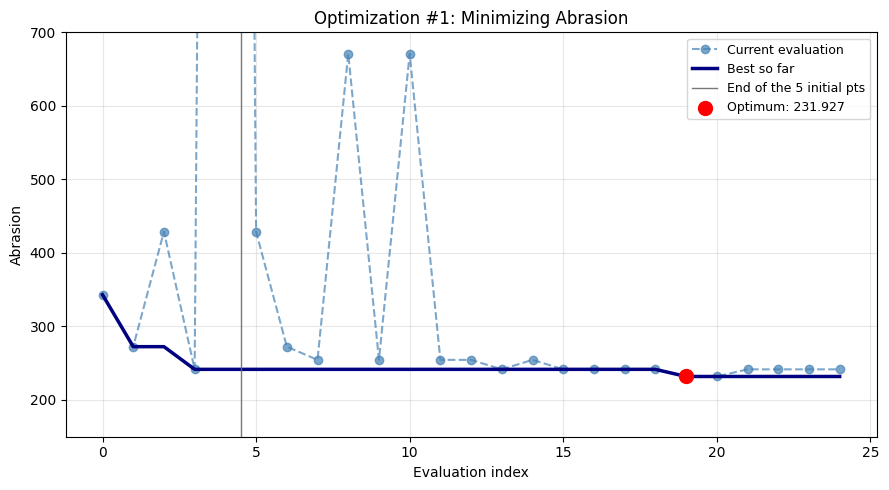

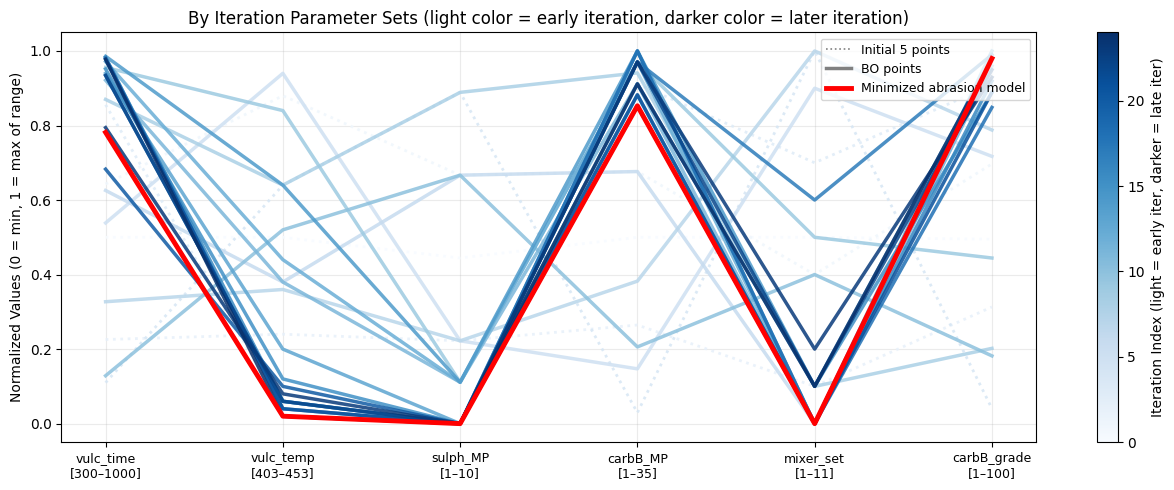

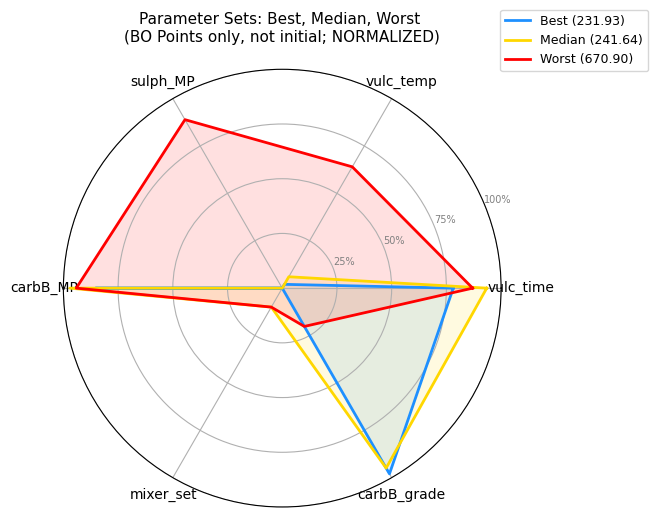

C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 1600x600 with 0 Axes>

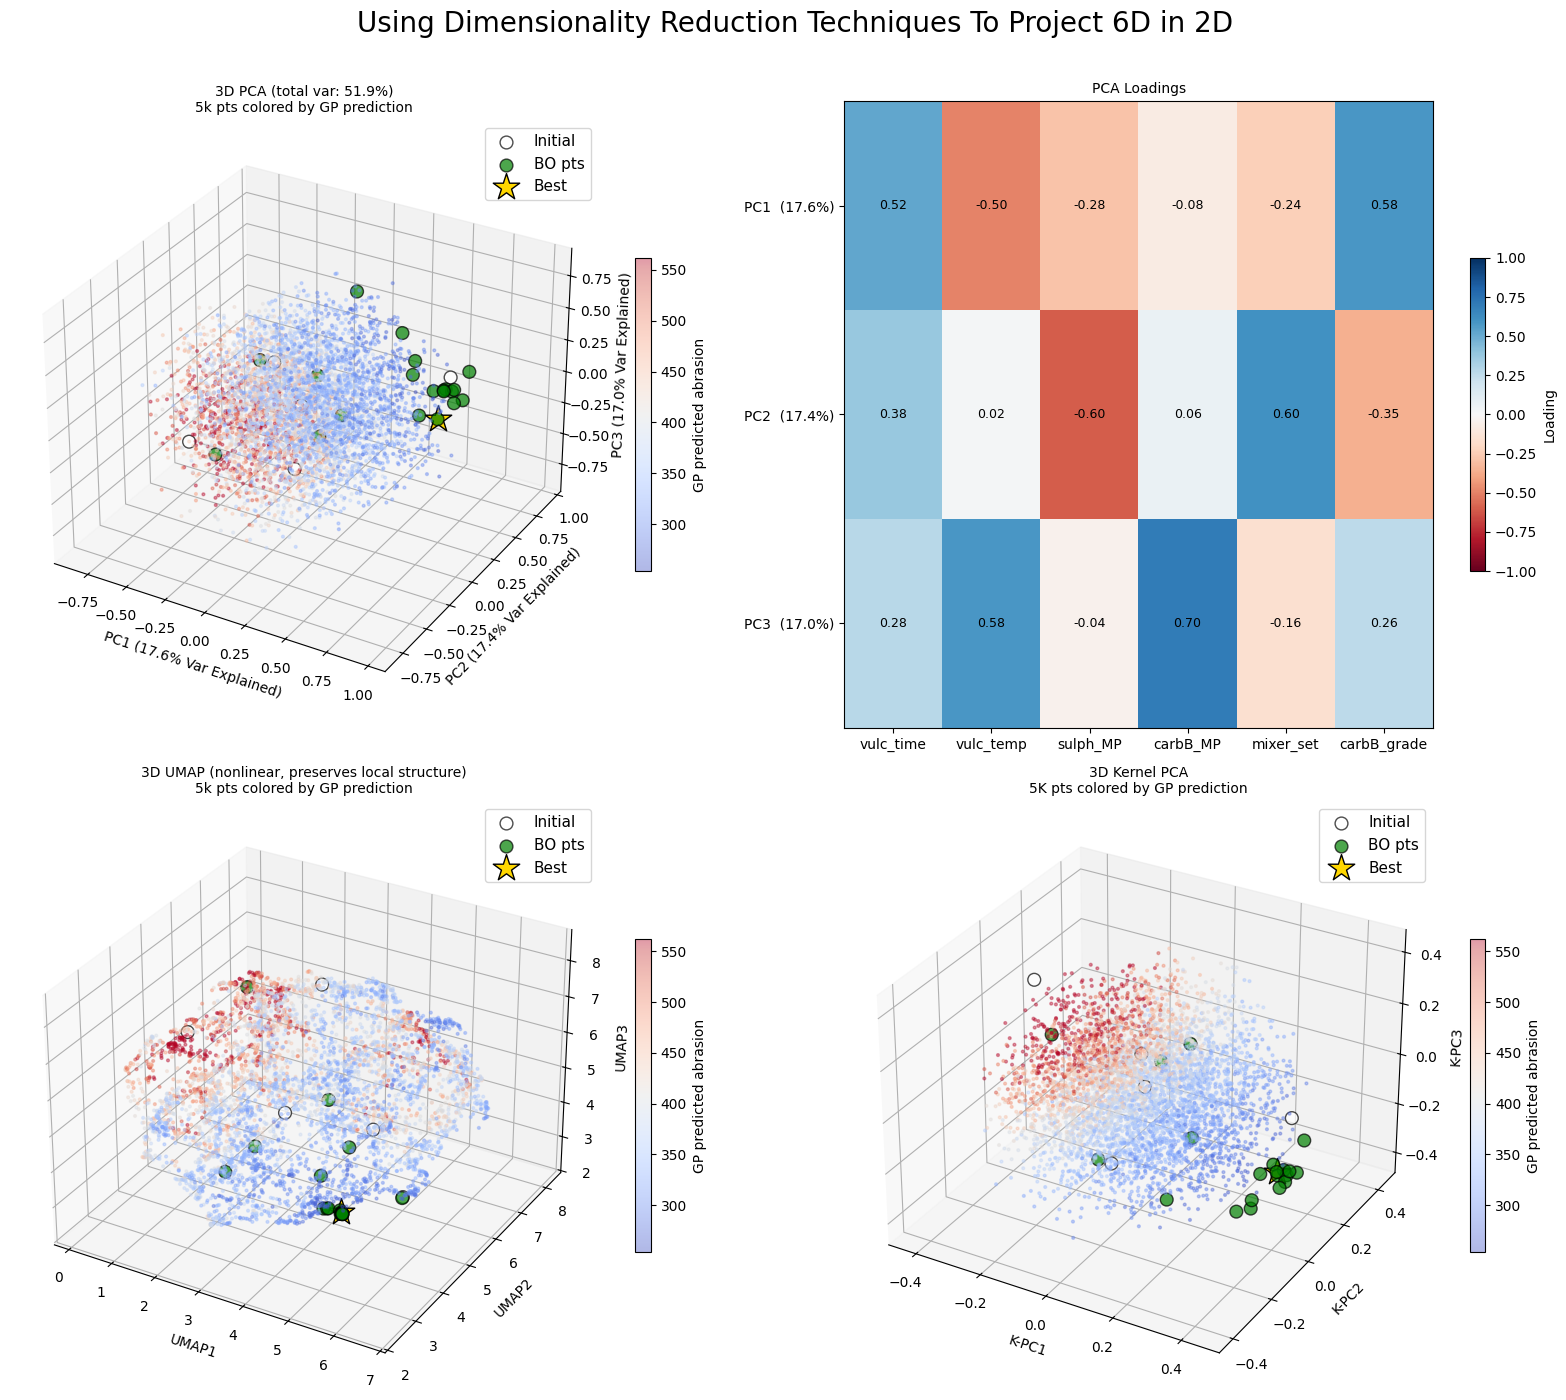


Eval   Type     vulc_time vulc_temp sulph_MP carbB_MP mixer_set carbB_grade     abrasion     roll_res     dry_grip
--------------------------------------------------------------------------------------------------------------
0      init          650      428        5       18        6       50       343.13     0.177265   0.00305107
1      init          750      447        7       24        5       70       272.48     0.140409   0.00174503
2      init          458      415        3       10        2       32       428.94     0.310208   0.00734680
3      init          899      405        1       32        8       91       241.64     0.232879   0.00975282
4      init          377      435        9        2       11        5      5794.26     0.155936   0.00074382
5      BO-1          677      450        3        6       10       72       428.94     0.234512   0.00456897
6      BO-2          738      422        7       24        1       96       272.48     0.146928   0.00210018
7      BO-

In [136]:
n_total = X_train_Abr.shape[1]
abrasion_vals = -Y_train_Abr # remove negation to plot
i_best = np.argmax(Y_train_Abr)
X_normed = scaler.transform(X_train_Abr.T).T

good_vals = abrasion_vals[abrasion_vals < 1000] # exclude the big outlier
norm_abr = mcolors.Normalize(vmin=good_vals.min(), vmax=good_vals.max())

######################################## PLOT #1 ########################################
fig, ax = plt.subplots(figsize=(9, 5))
best_curve = np.minimum.accumulate(abrasion_vals)
ax.plot(abrasion_vals, "o--", color="steelblue", label="Current evaluation", alpha=0.7)
ax.plot(best_curve, "-", color="navy", linewidth=2.5, label="Best so far")
ax.axvline(x = n_init - 0.5, color="dimgrey", linewidth = 1, alpha=0.9, label=f"End of the {n_init} initial pts")
ax.scatter(i_best, abrasion_vals[i_best], color="red", s=100, zorder=5, label=f"Optimum: {abrasion_vals[i_best]:.3f}")
ax.set_ylim(150, 700)
ax.set_xlabel("Evaluation index")
ax.set_ylabel("Abrasion")
ax.set_title("Optimization #1: Minimizing Abrasion")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

######################################## Plot #2 ########################################
fig, ax = plt.subplots(figsize=(13, 5))
iter_cmap = plt.cm.Blues
iter_norm = mcolors.Normalize(vmin=0, vmax=n_total - 1)
sm = cm.ScalarMappable(cmap=iter_cmap, norm=iter_norm)
sm.set_array([])

for i in range(n_total):
    lw = 2.5 if i >= n_init else 2.0
    ls = "-" if i >= n_init else ":"
    ax.plot(range(6), X_normed[:, i], color=iter_cmap(iter_norm(i)), linewidth=lw, linestyle=ls, alpha=0.85)
ax.plot(range(6), X_normed[:, i_best], color="red", linewidth=3.5, zorder=10, label=f"Best: abrasion = {abrasion_vals[i_best]:.2f}")
ax.set_xticks(range(6))
ax.set_xticklabels([f"{name}\n[{param_bounds[j,0]:.0f}–{param_bounds[j,1]:.0f}]" for j, name in enumerate(param_names)], fontsize=9)
ax.set_ylabel("Normalized Values (0 = min, 1 = max of range)")
ax.set_title("By Iteration Parameter Sets (light color = early iteration, darker color = later iteration)")

legend_els = [
    Line2D([0],[0], color="gray", lw=1.2, ls=":", label="Initial 5 points"),
    Line2D([0],[0], color="gray", lw=2.5, ls="-", label="BO points"),
    Line2D([0],[0], color="red", lw=3.5, label="Minimized abrasion model"),
]
ax.legend(handles= legend_els, fontsize=9, loc="upper right")
plt.colorbar(sm, ax=ax, label="Iteration Index (light = early iter, darker = late iter)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

######################################## PLOT #3 ########################################
BO_idx = np.arange(n_init, n_total)
abr_bo = abrasion_vals[BO_idx]
i_median = BO_idx[np.argsort(abr_bo)[len(abr_bo) // 2]]
i_worst = BO_idx[np.argmax(abr_bo)]

profiles = {f"Best ({abrasion_vals[i_best]:.2f})": X_normed[:, i_best],
    f"Median ({abrasion_vals[i_median]:.2f})": X_normed[:, i_median],
    f"Worst ({abrasion_vals[i_worst]:.2f})": X_normed[:, i_worst],}
radar_colors = ["dodgerblue", "gold", "red"]

angles = np.linspace(0, 2 * np.pi, 6, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for (label, vals), col in zip(profiles.items(), radar_colors):
    v = list(vals) + [vals[0]]
    ax.plot(angles, v, color=col, linewidth=2, label=label)
    ax.fill(angles, v, color=col, alpha=0.12)
ax.set_thetagrids(np.degrees(angles[:-1]), param_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="gray")
ax.set_title("Parameter Sets: Best, Median, Worst \n(BO Points only, not initial; NORMALIZED)", pad=20, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

######################################## PLOT #4 ########################################
rng_viz = np.random.default_rng(999)
X_samplePTS_viz = np.zeros((6, 5000))
for i in range(6): X_samplePTS_viz[i] = rng_viz.uniform(param_bounds[i, 0], param_bounds[i, 1], 5000)
mean_PTS, std_PTS = gp_abrasion.predict(scaler.transform(X_samplePTS_viz.T), return_std=True)
actual_mean_PTS = -mean_PTS

pca = PCA(n_components=3)
PCA_all = pca.fit_transform(scaler.transform(np.hstack([X_samplePTS_viz, X_train_Abr]).T))
PCA_PTS_coords, PCA_exp_coords = PCA_all[:5000], PCA_all[5000:]

CM_norm = mcolors.Normalize(vmin=actual_mean_PTS.min(), vmax=np.percentile(actual_mean_PTS, 95))
ev = pca.explained_variance_ratio_ * 100
fig = plt.figure(figsize=(16, 6))

X_all_sc = scaler.transform(np.hstack([X_samplePTS_viz, X_train_Abr]).T)

umap_reducer = umap.UMAP(n_components=3, random_state=42)
UMAP_all = umap_reducer.fit_transform(X_all_sc)
UMAP_PTS, UMAP_exp = UMAP_all[:5000], UMAP_all[5000:]

kpca = KernelPCA(n_components=3, kernel="rbf")
KPCA_all = kpca.fit_transform(X_all_sc)
KPCA_PTS, KPCA_exp = KPCA_all[:5000], KPCA_all[5000:]

def plot_obs(ax, PCA_exp_coords, n_init, i_best):
    ax.scatter(PCA_exp_coords[:n_init,0], PCA_exp_coords[:n_init,1], PCA_exp_coords[:n_init,2], c="white", edgecolors="black", s=85, zorder=5, label="Initial", alpha=0.7)
    ax.scatter(PCA_exp_coords[n_init:,0], PCA_exp_coords[n_init:,1], PCA_exp_coords[n_init:,2], c="green",  edgecolors="black", s=85, zorder=6, label="BO pts", alpha=0.7)
    ax.scatter(PCA_exp_coords[i_best,0], PCA_exp_coords[i_best,1], PCA_exp_coords[i_best,2], c="gold", edgecolors="black", s=400, marker="*", zorder=10000, label="Best")
fig = plt.figure(figsize=(16, 14))

##### PCA 3D Plot (1 PC per Cartesian direction)
ax0 = fig.add_subplot(221, projection="3d")
sc0 = ax0.scatter(PCA_PTS_coords[:,0], PCA_PTS_coords[:,1], PCA_PTS_coords[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax0, PCA_exp_coords, n_init, i_best)
fig.colorbar(sc0, ax=ax0, label="GP predicted abrasion", shrink=0.5)
ax0.set_xlabel(f"PC1 ({ev[0]:.1f}% Var Explained)")
ax0.set_ylabel(f"PC2 ({ev[1]:.1f}% Var Explained)")
ax0.set_zlabel(f"PC3 ({ev[2]:.1f}% Var Explained)")
ax0.set_title(f"3D PCA (total var: {ev.sum():.1f}%)\n5k pts colored by GP prediction", fontsize=10)
ax0.legend(fontsize=11)

##### PCA Loadings Plot
ax1 = fig.add_subplot(222)
loadings = pca.components_
im = ax1.imshow(loadings, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax1.set_xticks(range(6))
ax1.set_xticklabels(param_names, fontsize=10)
ax1.set_yticks(range(3))
ax1.set_yticklabels([f"PC{i+1}  ({ev[i]:.1f}%)" for i in range(3)], fontsize=10)
ax1.set_title("PCA Loadings", fontsize=10)
for r in range(3):
    for c in range(6):
        ax1.text(c, r, f"{loadings[r,c]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax1, label="Loading", shrink=0.5)

##### UMAP 3D Plot
ax2 = fig.add_subplot(223, projection="3d")
sc2 = ax2.scatter(UMAP_PTS[:,0], UMAP_PTS[:,1], UMAP_PTS[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax2, UMAP_exp, n_init, i_best)
fig.colorbar(sc2, ax=ax2, label="GP predicted abrasion", shrink=0.5)
ax2.set_xlabel("UMAP1")
ax2.set_ylabel("UMAP2")
ax2.set_zlabel("UMAP3")
ax2.set_title("3D UMAP (nonlinear, preserves local structure)\n5k pts colored by GP prediction", fontsize=10)
ax2.legend(fontsize=11)

##### Kernal PCA 3D Plot (nonlinear PCA, each PC is infinite dimensions, can't make heatmap)
ax3 = fig.add_subplot(224, projection="3d")
sc3 = ax3.scatter(KPCA_PTS[:,0], KPCA_PTS[:,1], KPCA_PTS[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax3, KPCA_exp, n_init, i_best)
fig.colorbar(sc3, ax=ax3, label="GP predicted abrasion", shrink=0.5)
ax3.set_xlabel("K-PC1")
ax3.set_ylabel("K-PC2")
ax3.set_zlabel("K-PC3")
ax3.set_title("3D Kernel PCA\n5K pts colored by GP prediction", fontsize=10)
ax3.legend(fontsize=11)

plt.suptitle("Using Dimensionality Reduction Techniques To Project 6D in 2D", fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

##### Summary table
print(f"\n{'Eval':<6} {'Type':<8}", end="")
for name in param_names:print(f" {name:>8}", end="")
print(f" {'abrasion':>12} {'roll_res':>12} {'dry_grip':>12}")
print("-" * 110)
for i in range(n_total):
    tag = "init" if i < n_init else f"BO-{i-n_init+1}"
    print(f"{i:<6} {tag:<8}", end="")
    for j in range(6):
        print(f" {X_train_Abr[j,i]:>8.0f}", end="")
    print(f" {abrasion_vals[i]:>12.2f} "
          f"{all_outputs_Abr['rolling_resistance'][i]:>12.6f} "
          f"{all_outputs_Abr['dry_grip'][i]:>12.8f}")

The goal of this optimization was to minimize abrasion in order to increase tire durability and longevity. This is important in regular and high-wear road applications like racing. 

The first plot tracks the abrasion value returned at each evaluation. The optimizer converges around evaluation 12, after which results stabilize near the optimum. Prior to that, there is a significant amount of noise as the GP explores the large parameter space with limited information. The best result was found at evaluation index 19 (index 19 in Python indexing, but the 20th actual iteration). It's interesting to note how close one of the 5 initial random points landed to the optimal region, giving the GP a bit more information prior. 

The second plot was meant to assign a visual shape to each parameter set, letting us track how the optimizer's suggstions evolved across iterations. Earlier iterations (the lighter lines) show irregular and sporadic shapes with no clear patterns. As iterations progressed (darker lines), a consistent shape starts to show as the optimizer is converging on a region of the parameter space. The optimal parameter set follows this converged shape closely. The transition is particularly visible between vulcanization temperature and sulphur mass fraction, where the optimizer narrows its search progressively. 

The next plot, the radar plot, compares the normalized parameter profiles of the best, median, and worst optimization points, excluding the random initialization points. I created this plot with assitance from Claude. Normalization ensures no parameter dominates by scale. The best tire compound (blue) shows vulcanization temperature, sulphur mass fraction, and mixer setting all at or near their minimum values, suggesting these three parameters are primary drivers of abrasion. Minimizing them jointly seems to produce the most durable compound. 

Since the parameter space is 6-dimensional, I applied dimensionality reduction to a set of 5000 randomly sampled test points evaluated by the trained GP, in order to visualize the structure of the learned response to the data with variable accessing and formatting assistance from Claude. The first method, Principal Component Analysis (PCA), constructs linear combinations of the input parameters that capture the axes of maximum variance. Because the 6 parameters were sampled independently by design (ex: vulc time does not depend on vulc temperature), PCA is unable to exploit covariance. Therefore, all three principal components (PCs) explain little variance, around 17% each. The point cloud is spherical and there is no clear separation between low and high abrasion regions. The loadings heatmap next to the 3D plot shows that no single parameter truly dominates each principal component. So I moved to nonlinear methods. UMAP is a nonlinear method that preserves local neighborhood structures rather than global variance. I assumed it would produce more clustering of low and high abrasion points compared to PCA, but there is still a fair amount of mixing. This is likely because the transition from low to high abrasion is gradual rather than discrete (a conclusion justified by the next dimensionality reduction technique). The final technique i used was kernel PCA, which maps the data into an infinite-dimensional space using radial basis functions before performing the reduction. This method produces a very clear separation, where low and high abrasion points create very distinct point clouds, with a gradual crossover region between them. The optimally minimized abrasion value sits at the outer edge of the low abrasion cloud, consistent with it representing an extreme of the response surface. 

The summary table reports abrasion, rolling resistance, and dry grip across all evaluations. The intent was to assess whether abrasion could be minimized without sacrificing grip. This is a meaningful tradeoff in motorsports applications where durability and handling performance have to coexist. The proper extension of this work would be a multi-objective optimization that jointly minimizes abrasion and rolling resistance while enforcing a lower boundary on dry grip. 


C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal 

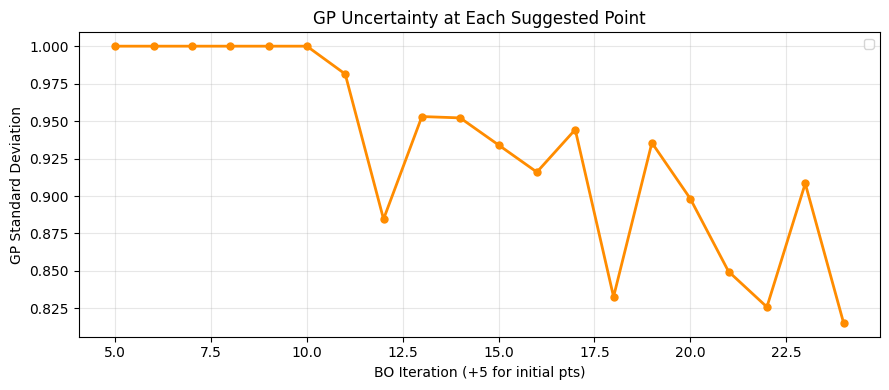

In [185]:
stds_Abr = []
gp_temp_RQ = GaussianProcessRegressor(kernel=RationalQuadratic())

for k in range(n_init, n_total): # refitting all points to produce uncertainty plot
    X_so_far = X_train_Abr[:, :k]
    y_so_far = Y_train_Abr[:k]
    gp_temp_RQ.fit(scaler.transform(X_so_far.T), y_so_far)

    x_chosen = X_train_Abr[:, k].reshape(1, -1)
    _, std_at_chosen = gp_temp_RQ.predict(scaler.transform(x_chosen), return_std=True)
    stds_Abr.append(std_at_chosen[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(n_init, n_total), stds_Abr, "o-", color="darkorange", linewidth=2, markersize=5)
ax.set_xlabel("BO Iteration (+5 for initial pts)")
ax.set_ylabel("GP Standard Deviation")
ax.set_title("GP Uncertainty at Each Suggested Point")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This plot shows the GP's uncertainty represented by its standard deviation at each suggested next point. It starts at evaluation number 5 (the first Bayesian Optimization iteration after initialization) and ends at the 20th and final Bayesian Optimization iteration. The uncertainty starts high and relatively stable as the GP has little data to work with, then decreases noisily as the model gathers more observations about the parameter space. The minimum uncertainty value also coincides with the optimal abrasion value found in iteration 20 (the final iteration in the loop) as expected since the optimizer commits to exploring a narrower parameter space rather than the full space explored in the first few iterations. 

### Summary Table

In [138]:
print("Evaluations for Optimization #1 (Abrasion Minimization):")
for i in range(X_train_Abr.shape[1]): print(f"  Point {i}: {dict(zip(param_names, X_train_Abr[:, i]))} --- abrasion = {-Y_train_Abr[i]:.4f}")

i_best_opt1 = np.argmax(Y_train_Abr)
X_best_opt1 = X_train_Abr[:, i_best_opt1]
print(f"\nBest point: {dict(zip(param_names, X_best_opt1))}")
print(f"Best abrasion value: {-Y_train_Abr[i_best_opt1]:.4f}")
print(f"Total evaluations: {X_train_Abr.shape[1]} (including {n_init} initial points)")

Evaluations for Optimization #1 (Abrasion Minimization):
  Point 0: {'vulc_time': np.float64(650.0), 'vulc_temp': np.float64(428.0), 'sulph_MP': np.float64(5.0), 'carbB_MP': np.float64(18.0), 'mixer_set': np.float64(6.0), 'carbB_grade': np.float64(50.0)} --- abrasion = 343.1310
  Point 1: {'vulc_time': np.float64(750.0), 'vulc_temp': np.float64(447.0), 'sulph_MP': np.float64(7.0), 'carbB_MP': np.float64(24.0), 'mixer_set': np.float64(5.0), 'carbB_grade': np.float64(70.0)} --- abrasion = 272.4794
  Point 2: {'vulc_time': np.float64(458.0), 'vulc_temp': np.float64(415.0), 'sulph_MP': np.float64(3.0), 'carbB_MP': np.float64(10.0), 'mixer_set': np.float64(2.0), 'carbB_grade': np.float64(32.0)} --- abrasion = 428.9430
  Point 3: {'vulc_time': np.float64(899.0), 'vulc_temp': np.float64(405.0), 'sulph_MP': np.float64(1.0), 'carbB_MP': np.float64(32.0), 'mixer_set': np.float64(8.0), 'carbB_grade': np.float64(91.0)} --- abrasion = 241.6364
  Point 4: {'vulc_time': np.float64(377.0), 'vulc_temp'

---
## Optimization #2: Minimize Rolling Resistance
Same 5 initial points used. Given the initial noisy convergence in the first optimization, I opted to change GP kernels as I did in the previous assignment. 

In [139]:
gp_rolling = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=10, normalize_y=True)
X_train_RR = X_train.copy()
Y_train_RR = -all_outputs["rolling_resistance"].copy() # negate also
all_outputs_RR = {name: all_outputs[name].copy() for name in output_names}

i_best = np.argmax(Y_train_RR)
print(f"Current best rolling resistance: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

Current best rolling resistance: 0.140409 (Point 2)


### Opt2: Iteration #1

In [140]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=55)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 726
---vulc_temp: 442
---sulph_MP: 7
---carbB_MP: 21
---mixer_set: 6
---carbB_grade: 71


In [141]:
new_RR_Iter1 = {
    "material_cost": 1061.1454422,
    "heating_cost": 14.731200000000001,
    "mixing_cost": 24.2685,
    "sound_damping": 0.06817709624337401,
    "rolling_resistance": 0.1409693100658347,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0017889192262328137,
    "wet_grip": 6.93979621
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter1["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter1[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter1['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.140969
Current best rolling res value: 0.140409 (Point 2)


The same sets of cells as in the first optimization are used here as well. The first cell calls the NextPoint function to use EI and output the next set of parameters to submit for experimentation. The second cell accepts the results of the experiment, and appends it to the training data.  

### Opt2: Iteration #2

In [142]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=56)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 693
---vulc_temp: 451
---sulph_MP: 8
---carbB_MP: 21
---mixer_set: 9
---carbB_grade: 37


In [143]:
new_RR_Iter2 = {
    "material_cost": 679.1461496,
    "heating_cost": 14.456500000000002,
    "mixing_cost": 43.6833,
    "sound_damping": 0.07510479740501141,
    "rolling_resistance": 0.13105614514713404,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.0013391471790120974,
    "wet_grip": 4.9234884899999996
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter2["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter2[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter2['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.131056
Current best rolling res value: 0.131056 (Point 7)


### Opt2: Iteration #3

In [144]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=57)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 961
---vulc_temp: 452
---sulph_MP: 10
---carbB_MP: 16
---mixer_set: 8
---carbB_grade: 50


In [145]:
new_RR_Iter3 = {
    "material_cost": 1245.3820079999998,
    "heating_cost": 11.5338,
    "mixing_cost": 48.537,
    "sound_damping": 0.06114803763518931,
    "rolling_resistance": 0.12613710217513907,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0011983503077240111,
    "wet_grip": 8.47221017
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter3["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter3[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter3['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.126137
Current best rolling res value: 0.126137 (Point 8)


### Opt2: Iteration #4

In [146]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=58)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 976
---vulc_temp: 439
---sulph_MP: 10
---carbB_MP: 31
---mixer_set: 9
---carbB_grade: 32


In [147]:
new_RR_Iter4 = {
    "material_cost": 235.0788852,
    "heating_cost": 11.258000000000001,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09738519404440563,
    "rolling_resistance": 0.12937513973565967,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0005017301188093229,
    "wet_grip": 1.971748395
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter4["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter4[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter4['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.129375
Current best rolling res value: 0.126137 (Point 8)


### Opt2: Iteration #5

In [148]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=59)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 879
---vulc_temp: 451
---sulph_MP: 10
---carbB_MP: 35
---mixer_set: 10
---carbB_grade: 94


In [149]:
new_RR_Iter5 = {
    "material_cost": 689.3288415,
    "heating_cost": 18.781200000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0662054964503036,
    "rolling_resistance": 0.11128230640510432,
    "abrasion": 343.1309573700778,
    "dry_grip": 0.0007220376466623565,
    "wet_grip": 6.746642879999999
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter5["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter5[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter5['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.111282
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #6

In [150]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=60)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 502
---vulc_temp: 450
---sulph_MP: 10
---carbB_MP: 31
---mixer_set: 11
---carbB_grade: 81


In [151]:
new_RR_Iter6 = {
    "material_cost": 748.8667041,
    "heating_cost": 16.0863,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.06576335539436724,
    "rolling_resistance": 0.11460952075560167,
    "abrasion": 343.1309573700778,
    "dry_grip": 0.0009396597777835468,
    "wet_grip": 6.030113699999999
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter6["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter6[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter6['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.114610
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #7

In [152]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=61)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 966
---vulc_temp: 441
---sulph_MP: 10
---carbB_MP: 13
---mixer_set: 11
---carbB_grade: 98


In [153]:
new_RR_Iter7 = {
    "material_cost": 1459.4115270000002,
    "heating_cost": 18.2031,
    "mixing_cost": 48.537,
    "sound_damping": 0.057734727769937474,
    "rolling_resistance": 0.1158835302707438,
    "abrasion": 272.4793710784738,
    "dry_grip": 0.0010016564189061087,
    "wet_grip": 8.11067075
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter7["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter7[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter7['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.115884
Current best rolling res value: 0.111282 (Point 10)


### Opt2: Iteration #8

In [154]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=62)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 664
---vulc_temp: 452
---sulph_MP: 10
---carbB_MP: 3
---mixer_set: 10
---carbB_grade: 99


In [155]:
new_RR_Iter8 = {
    "material_cost": 427.38735799999995,
    "heating_cost": 17.1396,
    "mixing_cost": 48.537,
    "sound_damping": 0.07884943138155623,
    "rolling_resistance": 0.10772313504733055,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0007012990452608617,
    "wet_grip": 2.75472731
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter8["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter8[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter8['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.107723
Current best rolling res value: 0.107723 (Point 13)


### Opt2: Iteration #9

In [156]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=63)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 642
---vulc_temp: 447
---sulph_MP: 10
---carbB_MP: 18
---mixer_set: 11
---carbB_grade: 96


In [157]:
new_RR_Iter9 = {
    "material_cost": 284.076109,
    "heating_cost": 14.603400000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.08805479322691845,
    "rolling_resistance": 0.10897654849216454,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0005107689798958431,
    "wet_grip": 1.598656997
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter9["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter9[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter9['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.108977
Current best rolling res value: 0.107723 (Point 13)


### Opt2: Iteration #10

In [158]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=64)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 791
---vulc_temp: 453
---sulph_MP: 7
---carbB_MP: 16
---mixer_set: 11
---carbB_grade: 93


In [159]:
new_RR_Iter10 = {
    "material_cost": 342.5082552,
    "heating_cost": 18.8048,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.08467411145390447,
    "rolling_resistance": 0.1035925408135647,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0004522895329770523,
    "wet_grip": 1.827301604
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter10["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter10[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter10['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.103593
Current best rolling res value: 0.103593 (Point 15)


### Opt2: Iteration #11

In [160]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=65)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 338
---vulc_temp: 451
---sulph_MP: 5
---carbB_MP: 10
---mixer_set: 11
---carbB_grade: 97


In [161]:
new_RR_Iter11 = {
    "material_cost": 268.592026,
    "heating_cost": 16.2176,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0886804055144444,
    "rolling_resistance": 0.10491538453456357,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00039931940614586697,
    "wet_grip": 1.3158819080000002
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter11["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter11[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter11['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.104915
Current best rolling res value: 0.103593 (Point 15)


### Opt2: Iteration #12

In [162]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=66)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 435
---vulc_temp: 452
---sulph_MP: 8
---carbB_MP: 8
---mixer_set: 11
---carbB_grade: 99


In [163]:
new_RR_Iter12 = {
    "material_cost": 227.1113026,
    "heating_cost": 18.736800000000002,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0881245146066701,
    "rolling_resistance": 0.10182409126740166,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002853741299671511,
    "wet_grip": 1.458163076
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter12["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter12[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter12['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101824
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #13

In [164]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=67)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 635
---vulc_temp: 452
---sulph_MP: 2
---carbB_MP: 3
---mixer_set: 11
---carbB_grade: 93


In [165]:
new_RR_Iter13 = {
    "material_cost": 238.52449239999999,
    "heating_cost": 18.0422,
    "mixing_cost": 48.537,
    "sound_damping": 0.08861214580349876,
    "rolling_resistance": 0.10230525291968406,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00028567747102836526,
    "wet_grip": 1.403702199
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter13["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter13[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter13['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.102305
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #14

In [166]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=68)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 622
---vulc_temp: 452
---sulph_MP: 6
---carbB_MP: 6
---mixer_set: 11
---carbB_grade: 86


In [167]:
new_RR_Iter14 = {
    "material_cost": 236.5333922,
    "heating_cost": 17.234,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.09116214691985933,
    "rolling_resistance": 0.10208568439304828,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002638351708526379,
    "wet_grip": 0.8833097859999999
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter14["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter14[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter14['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.102086
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #15

In [168]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=69)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 752
---vulc_temp: 453
---sulph_MP: 2
---carbB_MP: 16
---mixer_set: 11
---carbB_grade: 98


In [169]:
new_RR_Iter15 = {
    "material_cost": 225.0041942,
    "heating_cost": 18.2328,
    "mixing_cost": 53.390699999999995,
    "sound_damping": 0.0940407895965241,
    "rolling_resistance": 0.11084260674700923,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00033388132360750045,
    "wet_grip": 1.08400099
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter15["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter15[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter15['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.110843
Current best rolling res value: 0.101824 (Point 17)


### Opt2: Iteration #16

In [170]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=70)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 967
---vulc_temp: 450
---sulph_MP: 3
---carbB_MP: 3
---mixer_set: 11
---carbB_grade: 97


In [171]:
new_RR_Iter16 = {
    "material_cost": 275.585149,
    "heating_cost": 18.7866,
    "mixing_cost": 24.2685,
    "sound_damping": 0.08888749033597639,
    "rolling_resistance": 0.10166656513226409,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0003137195157940648,
    "wet_grip": 1.148665995
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter16["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter16[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter16['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101667
Current best rolling res value: 0.101667 (Point 21)


### Opt2: Iteration #17

In [172]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=71)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 650
---vulc_temp: 448
---sulph_MP: 5
---carbB_MP: 2
---mixer_set: 11
---carbB_grade: 97


In [173]:
new_RR_Iter17 = {
    "material_cost": 251.55953469999997,
    "heating_cost": 18.9508,
    "mixing_cost": 38.8296,
    "sound_damping": 0.08984798697808313,
    "rolling_resistance": 0.10122245910343115,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.00028741218255784527,
    "wet_grip": 0.9798125179999999
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter17["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter17[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter17['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101222
Current best rolling res value: 0.101222 (Point 22)


### Opt2: Iteration #18

In [174]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=72)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 425
---vulc_temp: 453
---sulph_MP: 5
---carbB_MP: 4
---mixer_set: 11
---carbB_grade: 99


In [175]:
new_RR_Iter18 = {
    "material_cost": 260.2022086,
    "heating_cost": 19.0953,
    "mixing_cost": 24.2685,
    "sound_damping": 0.08831886688707667,
    "rolling_resistance": 0.10159487228664324,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002807983550182083,
    "wet_grip": 1.39826458
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter18["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter18[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter18['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.101595
Current best rolling res value: 0.101222 (Point 22)


### Opt2: Iteration #19

In [176]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=73)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 723
---vulc_temp: 453
---sulph_MP: 5
---carbB_MP: 2
---mixer_set: 11
---carbB_grade: 93


In [177]:
new_RR_Iter19 = {
    "material_cost": 239.455622,
    "heating_cost": 19.0806,
    "mixing_cost": 29.1222,
    "sound_damping": 0.090275680357172,
    "rolling_resistance": 0.10090499193122549,
    "abrasion": 5794.259219712325,
    "dry_grip": 0.0002602584908443559,
    "wet_grip": 0.9389147899999999
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter19["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter19[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter19['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.100905
Current best rolling res value: 0.100905 (Point 24)


### Opt2: Iteration #20

In [178]:
x_next_RR = NextPoint(gp_rolling, X_train_RR, Y_train_RR, seed=74)
print("New parameter set:")
for name, val in zip(param_names, x_next_RR): print(f"---{name}: {val:.0f}")

New parameter set:
---vulc_time: 993
---vulc_temp: 450
---sulph_MP: 1
---carbB_MP: 4
---mixer_set: 11
---carbB_grade: 12


In [179]:
new_RR_Iter19 = {
    "material_cost": 742.2227547,
    "heating_cost": 16.342200000000002,
    "mixing_cost": 29.1222,
    "sound_damping": 0.06769663539435551,
    "rolling_resistance": 0.11370106616327533,
    "abrasion": 428.94298432566035,
    "dry_grip": 0.000990616349985573,
    "wet_grip": 5.0646483899999994
}

X_train_RR = np.append(X_train_RR, x_next_RR.reshape(6, 1), axis=-1)
Y_train_RR = np.append(Y_train_RR, -new_RR_Iter19["rolling_resistance"])
for name in output_names: all_outputs_RR[name] = np.append(all_outputs_RR[name], new_RR_Iter19[name])

i_best = np.argmax(Y_train_RR)
print(f"New rolling res: {new_RR_Iter19['rolling_resistance']:.6f}")
print(f"Current best rolling res value: {-Y_train_RR[i_best]:.6f} (Point {i_best+1})")

New rolling res: 0.113701
Current best rolling res value: 0.100905 (Point 24)


20 iterations completed, as in the first optimization process. 

## PLOTTING:

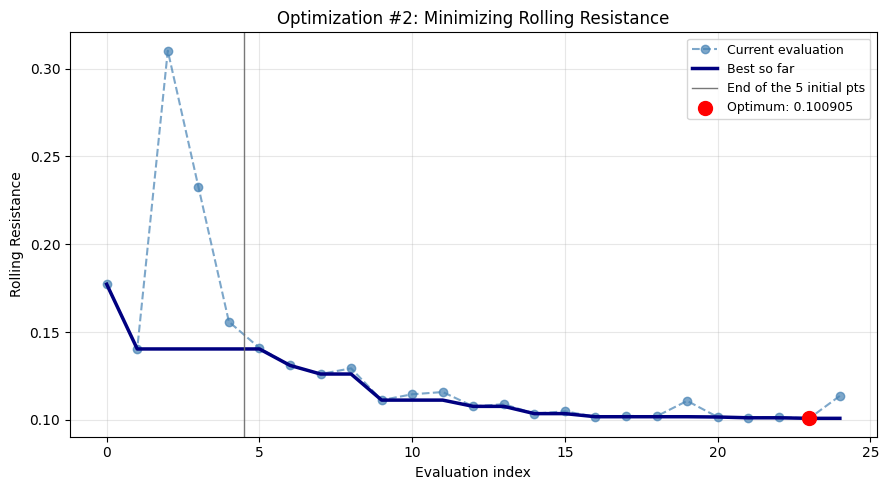

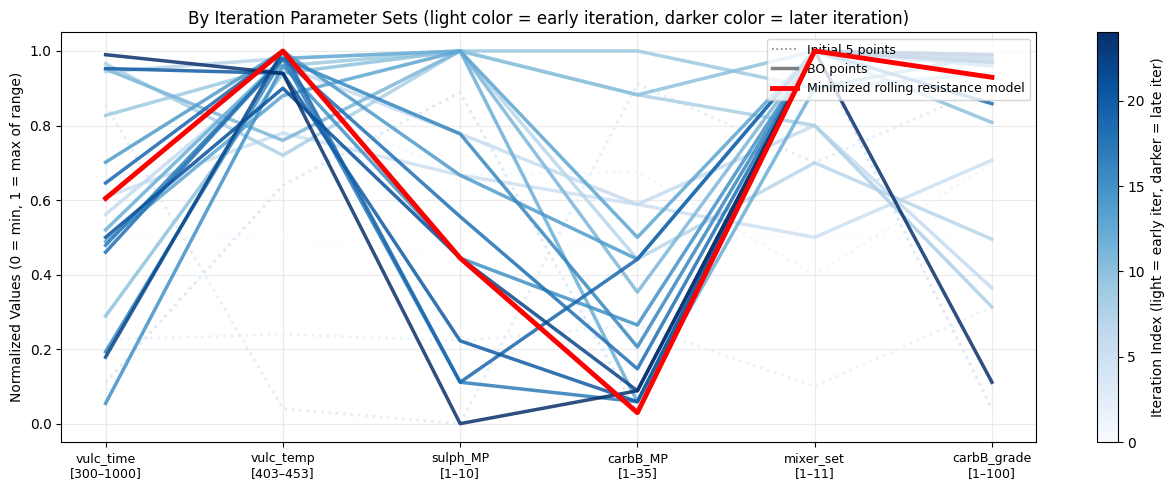

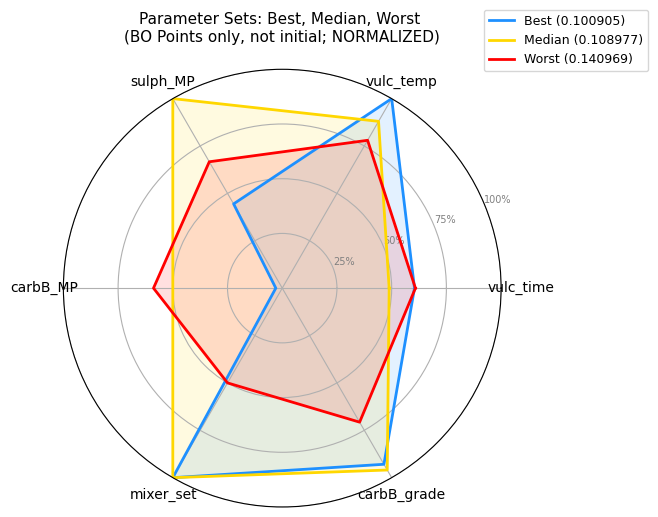

C:\Users\nikka\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


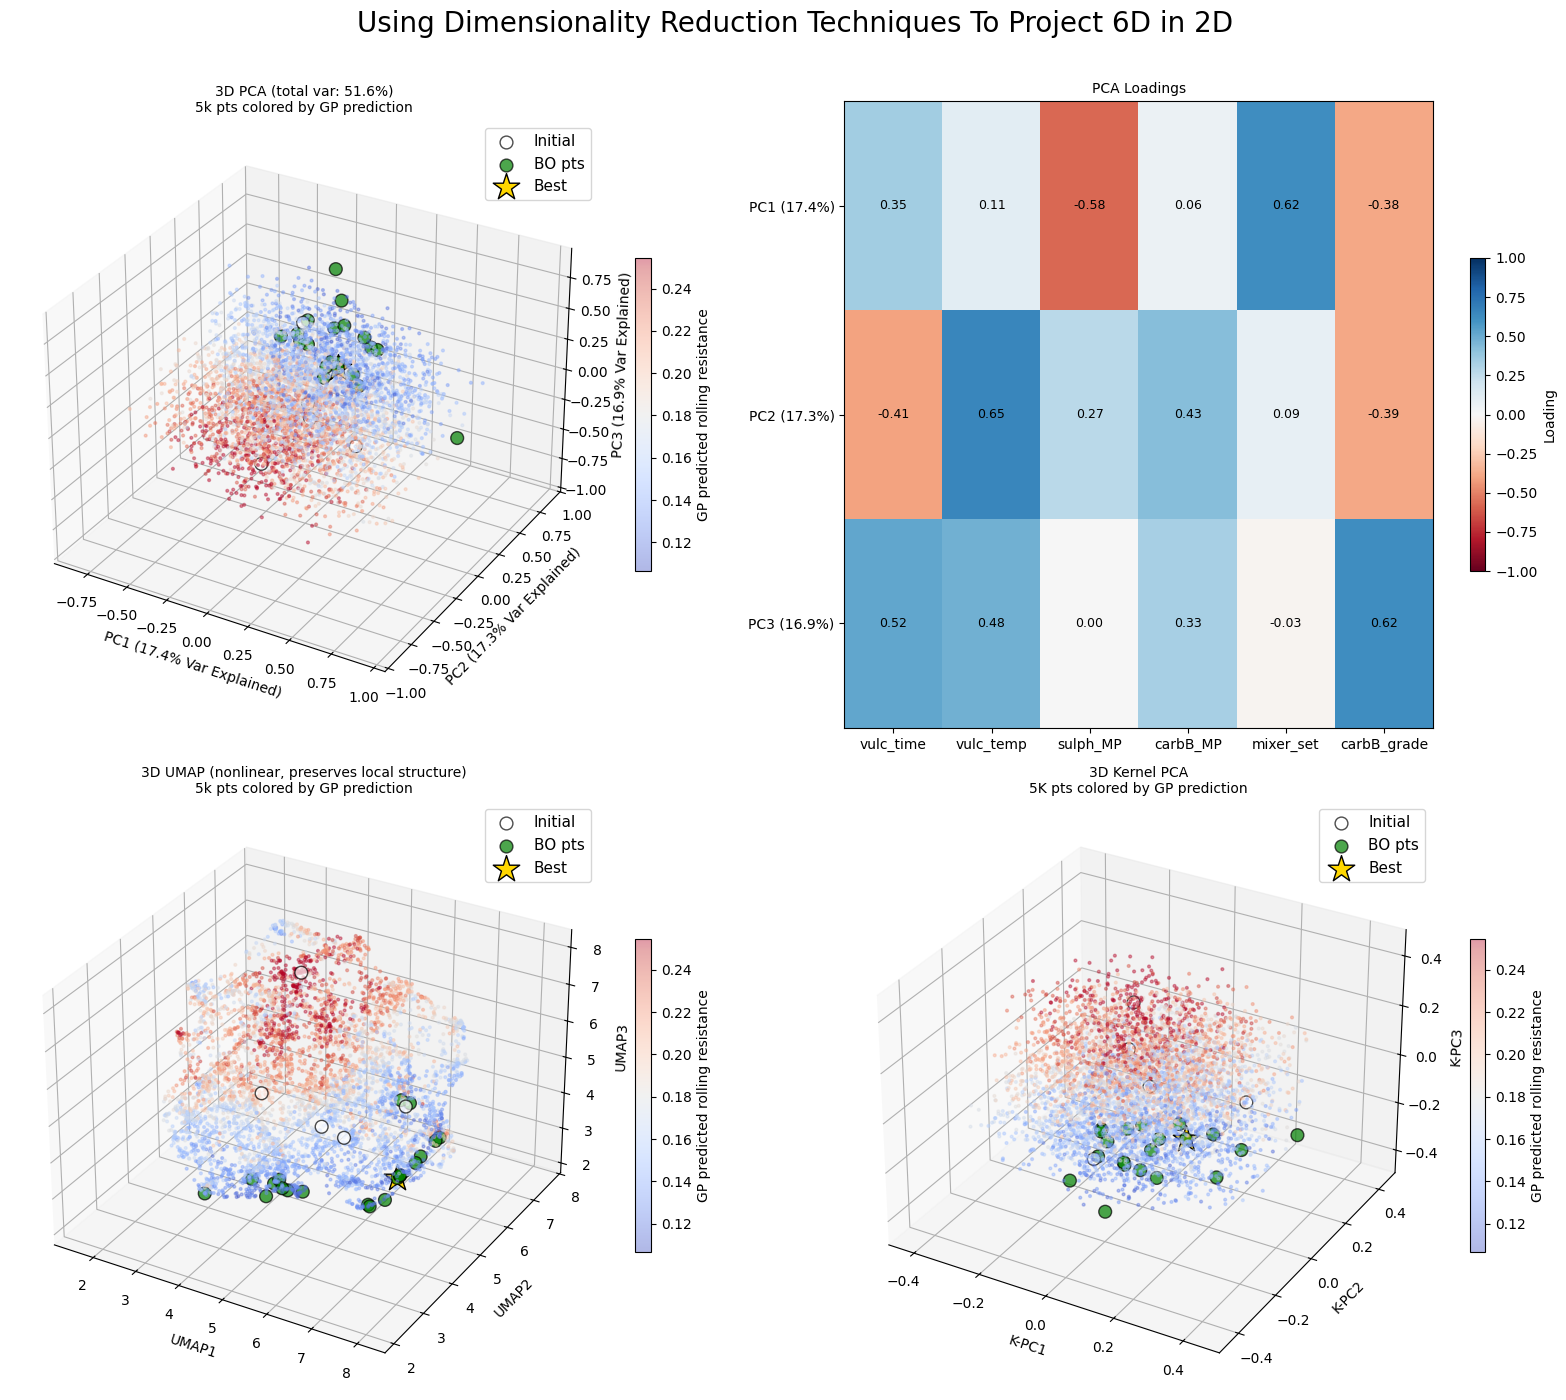


Eval   Type     vulc_time vulc_temp sulph_MP carbB_MP mixer_set carbB_grade  rolling_res     abrasion     dry_grip
--------------------------------------------------------------------------------------------------------------
0      init          650      428        5       18        6       50     0.177265       343.13   0.00305107
1      init          750      447        7       24        5       70     0.140409       272.48   0.00174503
2      init          458      415        3       10        2       32     0.310208       428.94   0.00734680
3      init          899      405        1       32        8       91     0.232879       241.64   0.00975282
4      init          377      435        9        2       11        5     0.155936      5794.26   0.00074382
5      BO-1          726      442        7       21        6       71     0.140969       272.48   0.00178892
6      BO-2          693      451        8       21        9       37     0.131056       428.94   0.00133915
7      BO-

In [180]:
"""Same plotting cell from optimization #1."""
n_total = X_train_RR.shape[1]
rr_vals = -Y_train_RR
i_best = np.argmax(Y_train_RR)
X_normed = scaler.transform(X_train_RR.T).T

good_vals = rr_vals[rr_vals < 1000]
norm_rr = mcolors.Normalize(vmin=good_vals.min(), vmax=good_vals.max())

######################################## PLOT #1 ########################################
fig, ax = plt.subplots(figsize=(9, 5))
best_curve = np.minimum.accumulate(rr_vals)
ax.plot(rr_vals, "o--", color="steelblue", label="Current evaluation", alpha=0.7)
ax.plot(best_curve, "-", color="navy", linewidth=2.5, label="Best so far")
ax.axvline(x=n_init - 0.5, color="dimgrey", linewidth=1, alpha=0.9, label=f"End of the {n_init} initial pts")
ax.scatter(i_best, rr_vals[i_best], color="red", s=100, zorder=5, label=f"Optimum: {rr_vals[i_best]:.6f}")
ax.set_xlabel("Evaluation index")
ax.set_ylabel("Rolling Resistance")
ax.set_title("Optimization #2: Minimizing Rolling Resistance")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

######################################## PLOT #2 ########################################
fig, ax = plt.subplots(figsize=(13, 5))
iter_cmap = plt.cm.Blues
iter_norm = mcolors.Normalize(vmin=0, vmax=n_total - 1)
sm = cm.ScalarMappable(cmap=iter_cmap, norm=iter_norm)
sm.set_array([])

for i in range(n_total):
    lw = 2.5 if i >= n_init else 2.0
    ls = "-"  if i >= n_init else ":"
    ax.plot(range(6), X_normed[:, i], color=iter_cmap(iter_norm(i)), linewidth=lw, linestyle=ls, alpha=0.85)
ax.plot(range(6), X_normed[:, i_best], color="red", linewidth=3.5, zorder=10, label=f"Best: rolling_res = {rr_vals[i_best]:.6f}")
ax.set_xticks(range(6))
ax.set_xticklabels([f"{name}\n[{param_bounds[j,0]:.0f}–{param_bounds[j,1]:.0f}]" for j, name in enumerate(param_names)], fontsize=9)
ax.set_ylabel("Normalized Values (0 = min, 1 = max of range)")
ax.set_title("By Iteration Parameter Sets (light color = early iteration, darker color = later iteration)")

legend_els = [
    Line2D([0],[0], color="gray", lw=1.2, ls=":", label="Initial 5 points"),
    Line2D([0],[0], color="gray", lw=2.5, ls="-", label="BO points"),
    Line2D([0],[0], color="red", lw=3.5, label="Minimized rolling resistance model"),
]
ax.legend(handles=legend_els, fontsize=9, loc="upper right")
plt.colorbar(sm, ax=ax, label="Iteration Index (light = early iter, darker = late iter)")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

######################################## PLOT #3 ########################################
BO_idx = np.arange(n_init, n_total)
rr_bo = rr_vals[BO_idx]
i_median = BO_idx[np.argsort(rr_bo)[len(rr_bo) // 2]]
i_worst = BO_idx[np.argmax(rr_bo)]

profiles = {f"Best ({rr_vals[i_best]:.6f})": X_normed[:, i_best],
    f"Median ({rr_vals[i_median]:.6f})": X_normed[:, i_median],
    f"Worst ({rr_vals[i_worst]:.6f})": X_normed[:, i_worst],}
radar_colors = ["dodgerblue", "gold", "red"]

angles = np.linspace(0, 2 * np.pi, 6, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
for (label, vals), col in zip(profiles.items(), radar_colors):
    v = list(vals) + [vals[0]]
    ax.plot(angles, v, color=col, linewidth=2, label=label)
    ax.fill(angles, v, color=col, alpha=0.12)
ax.set_thetagrids(np.degrees(angles[:-1]), param_names, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="gray")
ax.set_title("Parameter Sets: Best, Median, Worst \n(BO Points only, not initial; NORMALIZED)", pad=20, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

######################################## PLOT #4 ########################################
rng_viz = np.random.default_rng(999)
X_samplePTS_viz = np.zeros((6, 5000))
for i in range(6): X_samplePTS_viz[i] = rng_viz.uniform(param_bounds[i, 0], param_bounds[i, 1], 5000)
mean_PTS, std_PTS = gp_rolling.predict(scaler.transform(X_samplePTS_viz.T), return_std=True)
actual_mean_PTS = -mean_PTS

pca = PCA(n_components=3)
PCA_all = pca.fit_transform(scaler.transform(np.hstack([X_samplePTS_viz, X_train_RR]).T))
PCA_PTS_coords, PCA_exp_coords = PCA_all[:5000], PCA_all[5000:]

CM_norm = mcolors.Normalize(vmin=actual_mean_PTS.min(), vmax=np.percentile(actual_mean_PTS, 95))
ev = pca.explained_variance_ratio_ * 100

X_all_sc = scaler.transform(np.hstack([X_samplePTS_viz, X_train_RR]).T)

umap_reducer = umap.UMAP(n_components=3, random_state=42)
UMAP_all = umap_reducer.fit_transform(X_all_sc)
UMAP_PTS, UMAP_exp = UMAP_all[:5000], UMAP_all[5000:]

kpca = KernelPCA(n_components=3, kernel="rbf")
KPCA_all = kpca.fit_transform(X_all_sc)
KPCA_PTS, KPCA_exp = KPCA_all[:5000], KPCA_all[5000:]

def plot_obs(ax, PCA_exp_coords, n_init, i_best):
    ax.scatter(PCA_exp_coords[:n_init,0], PCA_exp_coords[:n_init,1], PCA_exp_coords[:n_init,2], c="white", edgecolors="black", s=85, zorder=5, label="Initial", alpha=0.7)
    ax.scatter(PCA_exp_coords[n_init:,0], PCA_exp_coords[n_init:,1], PCA_exp_coords[n_init:,2], c="green", edgecolors="black", s=85, zorder=6, label="BO pts", alpha=0.7)
    ax.scatter(PCA_exp_coords[i_best,0], PCA_exp_coords[i_best,1], PCA_exp_coords[i_best,2], c="gold", edgecolors="black", s=400, marker="*", zorder=10000, label="Best")
fig = plt.figure(figsize=(16, 14))

##### PCA 3D Plot (1 PC per Cartesian direction)
ax0 = fig.add_subplot(221, projection="3d")
sc0 = ax0.scatter(PCA_PTS_coords[:,0], PCA_PTS_coords[:,1], PCA_PTS_coords[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax0, PCA_exp_coords, n_init, i_best)
fig.colorbar(sc0, ax=ax0, label="GP predicted rolling resistance", shrink=0.5)
ax0.set_xlabel(f"PC1 ({ev[0]:.1f}% Var Explained)")
ax0.set_ylabel(f"PC2 ({ev[1]:.1f}% Var Explained)")
ax0.set_zlabel(f"PC3 ({ev[2]:.1f}% Var Explained)")
ax0.set_title(f"3D PCA (total var: {ev.sum():.1f}%)\n5k pts colored by GP prediction", fontsize=10)
ax0.legend(fontsize=11)

##### PCA Loadings Plot
ax1 = fig.add_subplot(222)
loadings = pca.components_
im = ax1.imshow(loadings, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax1.set_xticks(range(6))
ax1.set_xticklabels(param_names, fontsize=10)
ax1.set_yticks(range(3))
ax1.set_yticklabels([f"PC{i+1} ({ev[i]:.1f}%)" for i in range(3)], fontsize=10)
ax1.set_title("PCA Loadings", fontsize=10)
for r in range(3):
    for c in range(6):
        ax1.text(c, r, f"{loadings[r,c]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax1, label="Loading", shrink=0.5)

##### UMAP 3D Plot
ax2 = fig.add_subplot(223, projection="3d")
sc2 = ax2.scatter(UMAP_PTS[:,0], UMAP_PTS[:,1], UMAP_PTS[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax2, UMAP_exp, n_init, i_best)
fig.colorbar(sc2, ax=ax2, label="GP predicted rolling resistance", shrink=0.5)
ax2.set_xlabel("UMAP1")
ax2.set_ylabel("UMAP2")
ax2.set_zlabel("UMAP3")
ax2.set_title("3D UMAP (nonlinear, preserves local structure)\n5k pts colored by GP prediction", fontsize=10)
ax2.legend(fontsize=11)

##### Kernal PCA 3D Plot (nonlinear PCA, each PC is infinite dimensions, can't make loadgins heatmap)
ax3 = fig.add_subplot(224, projection="3d")
sc3 = ax3.scatter(KPCA_PTS[:,0], KPCA_PTS[:,1], KPCA_PTS[:,2], c=actual_mean_PTS, cmap="coolwarm", norm=CM_norm, s=4, alpha=0.4)
plot_obs(ax3, KPCA_exp, n_init, i_best)
fig.colorbar(sc3, ax=ax3, label="GP predicted rolling resistance", shrink=0.5)
ax3.set_xlabel("K-PC1")
ax3.set_ylabel("K-PC2")
ax3.set_zlabel("K-PC3")
ax3.set_title("3D Kernel PCA\n5K pts colored by GP prediction", fontsize=10)
ax3.legend(fontsize=11)

plt.suptitle("Using Dimensionality Reduction Techniques To Project 6D in 2D", fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

##### Summary Stats:
print(f"\n{'Eval':<6} {'Type':<8}", end="")
for name in param_names:
    print(f" {name:>8}", end="")
print(f" {'rolling_res':>12} {'abrasion':>12} {'dry_grip':>12}")
print("-" * 110)
for i in range(n_total):
    tag = "init" if i < n_init else f"BO-{i-n_init+1}"
    print(f"{i:<6} {tag:<8}", end="")
    for j in range(6):
        print(f" {X_train_RR[j,i]:>8.0f}", end="")
    print(f" {rr_vals[i]:>12.6f} "
          f"{all_outputs_RR['abrasion'][i]:>12.2f} "
          f"{all_outputs_RR['dry_grip'][i]:>12.8f}")

The convergence plot tells a similar story to Optimization #1, but the Matern kernel produces notably cleaner behavior. Past the initialization boundary, there are no large spikes back toward high rolling resistance values. The optimizer commits to the low resistance region early and refines steadily from there. The optimum was found at evaluation index 24 (the 19th BO iteration after the 5 initialization points).

The same convergence behavior visible in Optimization #1 appears in the parameter set plot. Early iterations (lighter lines) are exploratory with no consistent shape, while later iterations (darker lines) progressively narrow toward the shape of the optimal parameter set (red). The darkest lines follow the optimum with minor deviations at a few parameters, confirming the optimizer had largely converged by the final iterations.

The radar plot appears very different compared to that produced from Optimization #1. Rather than pushing multiple parameters to their minimum values, the dominant signal is carbon black mass fraction, which is driven strongly downward. This suggests that reducing carbon black content is a primary factor for lowering rolling resistance. Vulcanization temperature and mixer settings are both pushed toward their maximum value. It's possible incorporating less carbon black in the compound requires more aggressive processing condition to maintain the compound's integrity. 

PCA shows marginally better separation of low and high resistance points compared to the first optimization, though the PCs still explain little individual variance. The loadings heatmap is still distributed, with several parameters carrying large weight across multiple components. UMAP produces cleaner clustering than the first optimization, with more distinct groupings visible at both ends of the resistance spectrum. The presence of outlier clusters on either side does not bode well for the method's ability to create the smooth, continuous gradient between the resistance extremes. KPCA performs well but with more spread in the crossover region compared to the first optimization, suggesting the boundary between low and high resistance regions is not as sharp as it was for abrasion. The optimal point sits at the outer extent of the cloud along the KPC3 axis. 

Overall, the radar plot is th most interpretable output from this optimization, as it directly maps parameter values to the achieved outcome. A valuable follow up would be to plot the parameter profiles of the 3 evaluations closest to the optimum to quantify how much parameter valiration is tolerable while still achieving near-optimal rolling resistance. 

C:\Users\nikka\AppData\Local\Temp\ipykernel_16260\1321797289.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


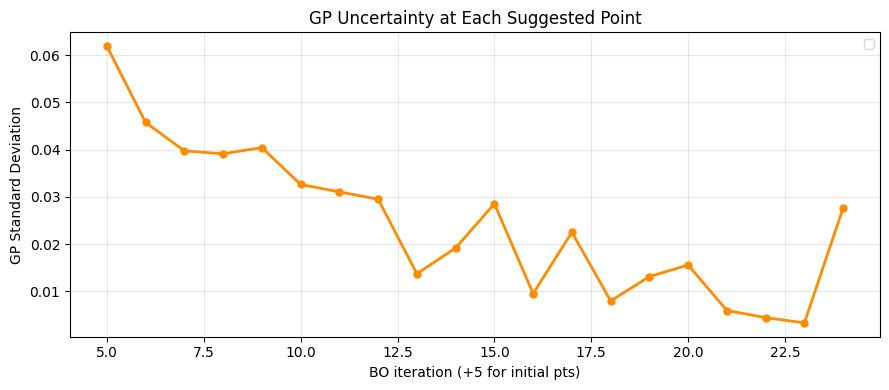

In [186]:
stds_RR = []
gp_temp_Matern = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=10, normalize_y=True)

for k in range(n_init, X_train_RR.shape[1]): # refitting all points to produce uncertainty plot
    X_so_far = X_train_RR[:, :k]
    y_so_far = Y_train_RR[:k]
    gp_temp_Matern.fit(scaler.transform(X_so_far.T), y_so_far)

    x_chosen = X_train_RR[:, k].reshape(1, -1)
    _, std_at_chosen = gp_temp_Matern.predict(scaler.transform(x_chosen), return_std=True)
    stds_RR.append(std_at_chosen[0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(n_init, X_train_RR.shape[1]), stds_RR, "o-", color="darkorange", linewidth=2, markersize=5)
ax.set_xlabel("BO iteration (+5 for initial pts)")
ax.set_ylabel("GP Standard Deviation")
ax.set_title("GP Uncertainty at Each Suggested Point")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This plot operates the same as in optimization #1, showing standard deviation over each optimization iteration. The minmum rolling resistance was found at evaluation number 24 which corresponds to Bayesian Optimization iteration 19. This point is where the minium uncertainty value is produced. This makes sense, since by the final iteration the model has narrowed its search to a well-explored region of the 6D parameter space and more finely converges on the minimum. The declining trend is noisy but more consistent than in optimization #1, with a clear overall reduction in uncertainty over the 20 iterations. The spike at the very end could be due to the GP briefly exploring another unfamilir region of the parameter space where it had high uncertainty. But since the magnitude of rolling resistance did not change much over successful minimization steps, I opted not to continue. 

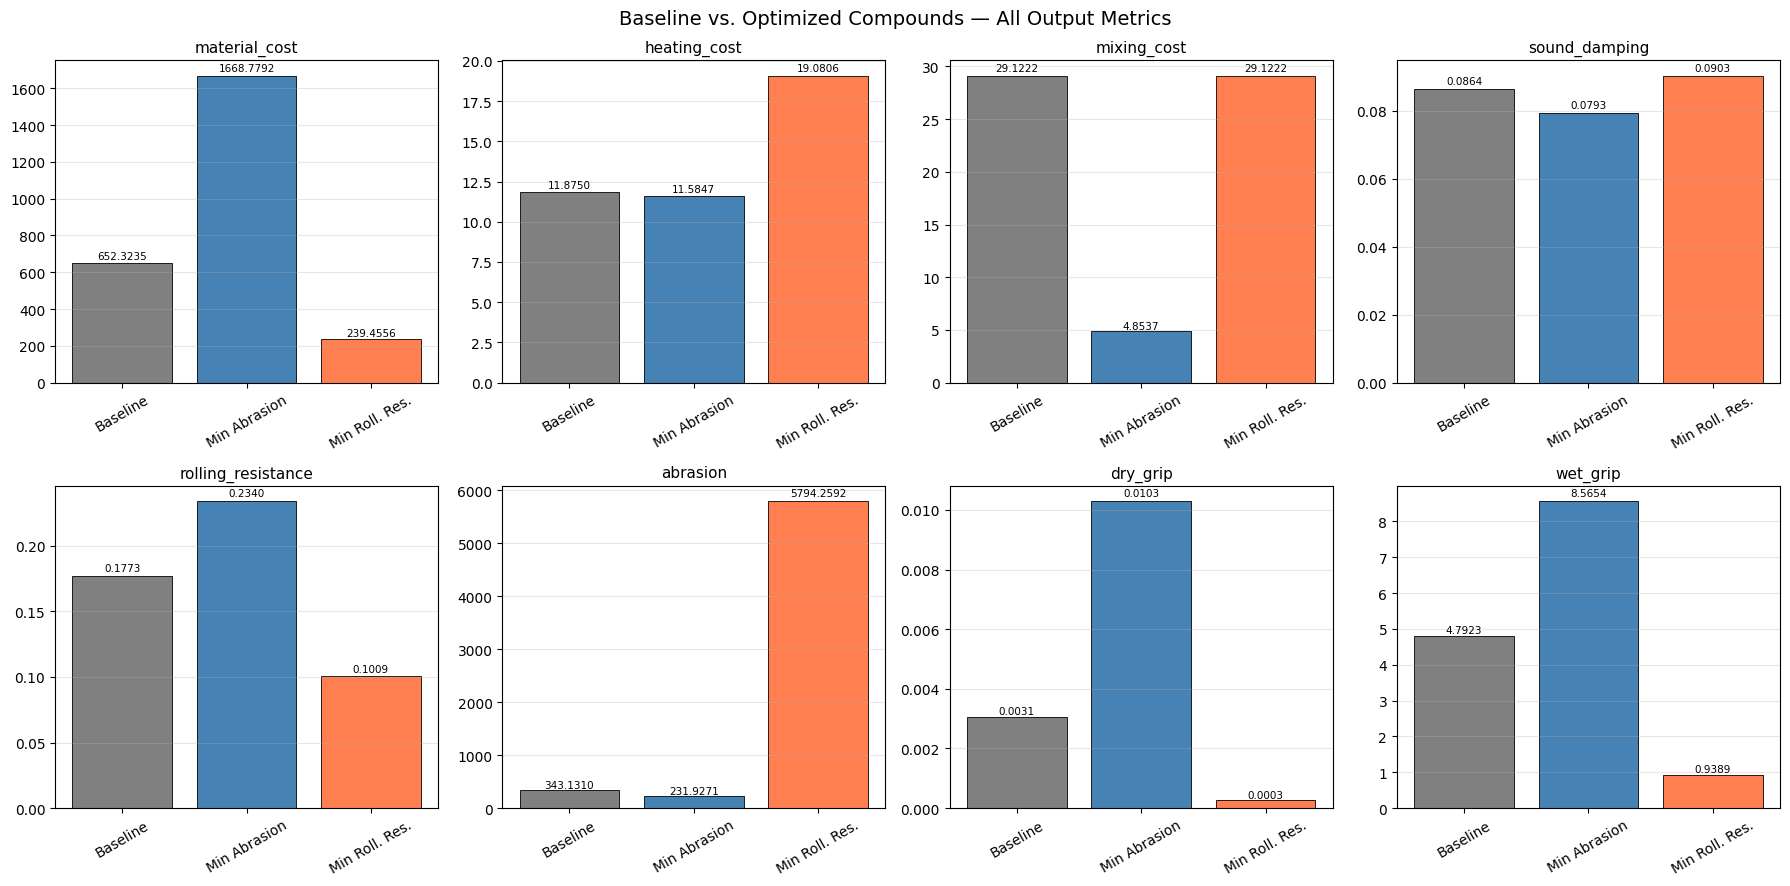

In [182]:
baseline_idx = 0
i_best_opt1 = np.argmax(Y_train_Abr)
i_best_B = np.argmax(Y_train_RR)

all_metrics = ["material_cost", "heating_cost", "mixing_cost", "sound_damping",
               "rolling_resistance", "abrasion", "dry_grip", "wet_grip"]

baseline_vals = [all_outputs_Abr[m][baseline_idx] for m in all_metrics]
opt_a_vals = [all_outputs_Abr[m][i_best_opt1] for m in all_metrics]
opt_b_vals = [all_outputs_RR[m][i_best_B] for m in all_metrics]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for idx, metric in enumerate(all_metrics):
    vals = [baseline_vals[idx], opt_a_vals[idx], opt_b_vals[idx]]
    colors = ["gray", "steelblue", "coral"]
    labels = ["Baseline", "Min Abrasion", "Min Roll. Res."]
    bars = axes[idx].bar(labels, vals, color=colors, edgecolor="black", linewidth=0.6)
    axes[idx].set_title(metric, fontsize=11)
    axes[idx].tick_params(axis="x", rotation=30)
    axes[idx].grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, vals):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                       f"{val:.4f}", ha="center", va="bottom", fontsize=7.5)

plt.suptitle("Baseline vs. Optimized Compounds — All Output Metrics", fontsize=14)
plt.tight_layout()
plt.show()

This is a fun plot I made with the assistance of Claude, to show how every output metric of the tire compound changes when I optimize for minimum abrasion versus minimum rolling resistance, benchmarked against the baseline compound. Creating an abrasion optimized compound seems incredibly expensive, but also very beneficial for grip. Another interesting comparison is between models for mixing cost. The minimal abrasion model is much cheaper to mix, likely because of the minimization made to mixing setting and sulphur mass fraction (less content to homogenize).